<a href="https://colab.research.google.com/github/bpickett14/AdvancedStatisticalMethods/blob/main/WrittenReport19.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Brenna Bunderson - Written Report Ch 19

In [ ]:
install.packages("Sleuth3")
install.packages("ggplot2")
install.packages("tidyr")
library(Sleuth3)
library(ggplot2)
library(tidyr)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
head(ex1921)

,Diet,DroppedOut,Completed
,<fct>,<int>,<int>
1,LowFat,10,94
2,Medit,16,83
3,LowCarb,24,85


#Introduction: Describe the Data and Present the Question
Weight-loss studies often compare not only the effectiveness of different diets, but also participants’ ability to adhere to them. In a study comparing three diet types - Low Fat, Mediterranean (Medit), and Low Carbohydrate (Low Carb) - researchers recorded the number of participants who completed the study and the number who dropped out of each diet group.

This raises an important question: Is there statistical evidence that dropout rates differ among the three diet types, or could the observed differences be due to random variation? To answer this question, we will analyze the relationship between diet type and study completion status using appropriate methods for categorical data.

#Graphical Analysis

In [ ]:
ex1921$Diet <- factor(ex1921$Diet, levels = c("LowFat", "Medit", "LowCarb"))

ex1921_long <- ex1921 %>%
  pivot_longer(
    cols = c(DroppedOut, Completed),
    names_to = "Status",
    values_to = "Count"
  )

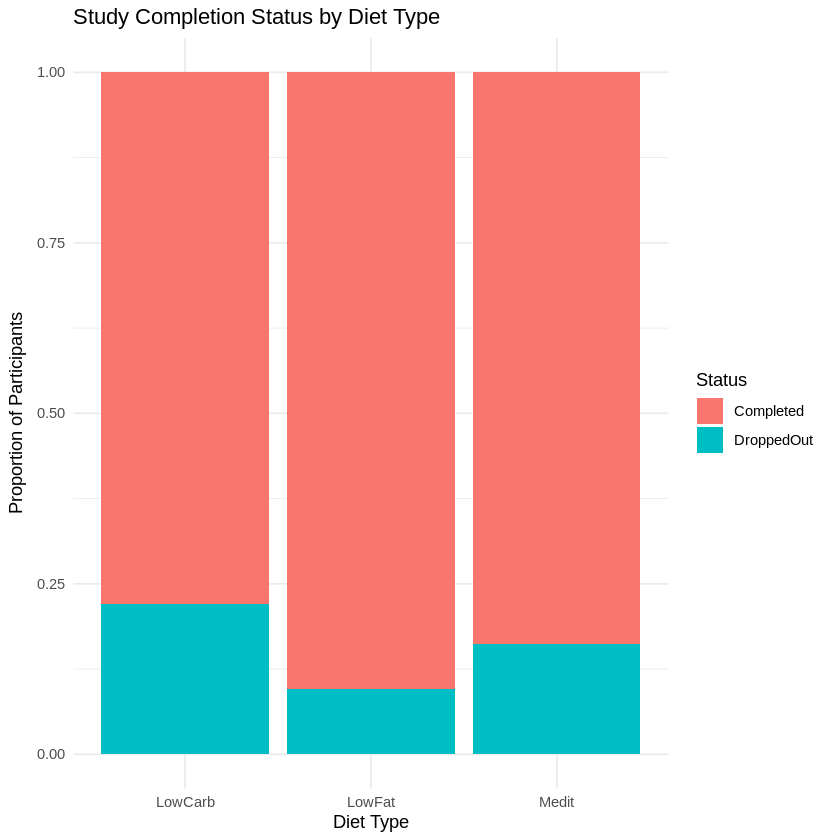

In [ ]:
# Now plot
ggplot(ex1921_long, aes(x = Diet, y = Count, fill = Status)) +
  geom_bar(stat = "identity", position = "fill") +
  labs(title = "Study Completion Status by Diet Type",
       x = "Diet Type",
       y = "Proportion of Participants") +
  theme_minimal()

In [ ]:
observed_table <- xtabs(Count ~ Diet + Status, data = ex1921_long)

# Chi-square test
chi_square_test_result <- chisq.test(observed_table)
expected_table <- chi_square_test_result$expected

# Print tables in original order
cat("Observed Frequencies Table:\n")
print(observed_table)

cat("\nExpected Frequencies Table:\n")
print(round(expected_table, 2))

Observed Frequencies Table:
         Status
Diet      Completed DroppedOut
  LowFat         94         10
  Medit          83         16
  LowCarb        85         24

Expected Frequencies Table:
         Status
Diet      Completed DroppedOut
  LowFat      87.33      16.67
  Medit       83.13      15.87
  LowCarb     91.53      17.47


#Assumptions
In analyzing these data, we could consider either Fisher’s Exact Test or the chi-square test of homogeneity. Fisher’s test is typically used for small samples or when expected cell counts are low, particularly in 2×2 tables. However, this study involves a 3×2 contingency table with a relatively large total sample size (n = 312). All expected cell counts exceed 5, so the large-sample conditions required for the chi-square approximation are satisfied. Therefore, the chi-square test is both appropriate and the more conventional choice for this analysis.

The chi-square test also assumes independence of observations. This condition is reasonable because each participant followed only one diet group and contributes to only one outcome (either completed or dropped out). With independence satisfied and all expected counts sufficiently large, the assumptions for the chi-square test are met.

#Statistical Conclusion

In [ ]:
print(chi_square_test_result)


	Pearson's Chi-squared test

data:  observed_table
X-squared = 6.0857, df = 2, p-value = 0.0477



H₀: rates of dropping out are equal across all three diets

Hₐ: one or more of the drop out rates are not equal

A chi-square test of homogeneity was conducted to determine whether dropout rates differ among the three diet groups. The test yielded a chi-square statistic of 6.09 with 2 degrees of freedom and a p-value of 0.0477. This is suggestive of a difference in dropout rates across the Low Fat, Mediterranean, and Low Carbohydrate diet groups.

The observed counts indicate that the Low Carbohydrate group had more dropouts than would be expected if dropout rates were equal across diets, suggesting that diet type may influence study completion.

#Scope of Inference
The description of the study (in chapter 6) states that participants were randomly assigned to diet groups. Therefore, it is most appropriate to treat this as a designed experiment in which individuals followed one of three diets and were then followed to determine whether they completed or dropped out. Because participants were randomly classified by diet, the sampling scheme is consistent with a randomized experiment framework.

Since this appears to be a designed, randomized experiment, causal conclusions can be made. We can conclude that there is a causation between diet type and dropout status. As always, other unmeasured factors, such as participant motivation, prior dietary preferences, or lifestyle differences, may also influence completion rates and could contribute to the observed differences.

The conclusions of this analysis apply only to populations similar to those represented in the study sample, such as individuals willing to participate in a structured diet program. While the p-value (0.0477) provides evidence against the null hypothesis of equal dropout rates, it is only slightly below the 0.05 significance level. Therefore, the evidence should be considered suggestive rather than strongly convincing.